# 高含水外挿: Tweedie GLM と exp/GBM 2段モデル × (quad / exp 基底)

今回の知見(乾物バンド/単調/非線形当てはまり)を活かし、2手法 × 2基底で LOSO 比較する。

**A. Tweedie GLM(log-link)**  `MC = exp(linear predictor)`、正・右歪み・分散∝平均^p を仮定。
  - A-exp : 線形予測子 = z (→ MC=exp(Σβz)、指数モデル)
  - A-quad: 線形予測子 = [z, z²] (→ MC=exp(Σβz+γz²)、指数内2次)

**B. 2段(パラメトリック基底 + GBM残差)** 基底が外挿を担い、GBMが範囲内を精緻化。
  - B-exp : 基底=Σβ·exp(B_j z_j) を Ridge → 残差を LightGBM
  - B-quad: 基底=Σ(β z+γ z²) を Ridge → 残差を LightGBM

指標 LOSO macro-RMSE。注目 **ベイスギ**(MC298%, 学習上限216%超=外挿)。特徴は乾物5バンド。

In [1]:
import numpy as np, pandas as pd
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit
from sklearn.linear_model import Ridge, TweedieRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb

tr=pd.read_csv('../data/train_clean.csv',encoding='shift_jis')
META=['sample number','species number','樹種','含水率']
wn_cols=[c for c in tr.columns if c not in META]
wn=np.array([float(c) for c in wn_cols]); wl=1e7/wn; order=np.argsort(wl); nm=wl[order]
X=tr[wn_cols].values.astype(float)[:,order]
mc=tr['含水率'].values.astype(float); sp=tr['樹種'].values; species=np.unique(sp)
snv=lambda M:(M-M.mean(1,keepdims=True))/(M.std(1,keepdims=True)+1e-8)
sg =lambda M,d:savgol_filter(M,11,2,deriv=d,axis=1)
S,S1,S2=snv(X),sg(snv(X),1),sg(snv(X),2)
bd=lambda M,lo,hi: M[:,(nm>=lo)&(nm<=hi)].mean(1)
Fmat=np.column_stack([bd(S1,1260,1300),bd(S2,1700,1740),bd(S2,2300,2340),
                      bd(S2,2200,2240),bd(S,2340,2400)])
fnames=['CH1270','CH1715','CH2320','CH2210','CL2360']
print('F', Fmat.shape, '| MC %.1f-%.1f%%'%(mc.min(),mc.max()))

F (1270, 5) | MC 0.8-298.6%


## モデル実装
全て fit/predict を持ち、標準化は学習側統計で(リーク無し)。

In [2]:
CLIP=20.0
class Std:
    def fit(self,X): self.mu=X.mean(0); self.sd=X.std(0)+1e-9; return self
    def z(self,X): return (X-self.mu)/self.sd

def quad_basis(Z): return np.hstack([Z, Z**2])            # 加法的に z と z²
def fit_expB(Z,y):                                         # 各列の exp 係数 B_j
    B=[]
    for j in range(Z.shape[1]):
        try:
            p,_=curve_fit(lambda x,A,Bj,C:A*np.exp(np.clip(Bj*x,-CLIP,CLIP))+C,
                          Z[:,j],y,p0=[y.std(),0.5,y.mean()],maxfev=20000)
            B.append(np.clip(p[1],-3,3))
        except Exception: B.append(0.3)
    return np.array(B)
exp_basis=lambda Z,B: np.exp(np.clip(Z*B,-CLIP,CLIP))

# --- A. Tweedie GLM(log link) ---
class TweedieA:
    def __init__(self,basis='exp',power=1.5,alpha=0.3):
        self.basis=basis; self.power=power; self.alpha=alpha
    def _phi(self,Z): return Z if self.basis=='exp' else quad_basis(Z)
    def fit(self,X,y):
        self.s=Std().fit(X); P=self._phi(self.s.z(X))
        self.ps=Std().fit(P); 
        self.m=TweedieRegressor(power=self.power,alpha=self.alpha,link='log',max_iter=5000)
        self.m.fit(self.ps.z(P),y); return self
    def predict(self,X):
        P=self._phi(self.s.z(X)); return np.clip(self.m.predict(self.ps.z(P)),0,400)

# --- B. 2段: パラメトリック基底(Ridge) + GBM残差 ---
class TwoStageB:
    def __init__(self,basis='exp',alpha=1.0):
        self.basis=basis; self.alpha=alpha
    def _phi(self,Z):
        return exp_basis(Z,self.B) if self.basis=='exp' else quad_basis(Z)
    def fit(self,X,y):
        self.s=Std().fit(X); Z=self.s.z(X)
        if self.basis=='exp': self.B=fit_expB(Z,y)
        P=self._phi(Z); self.ps=Std().fit(P)
        self.base=Ridge(self.alpha).fit(self.ps.z(P),y)         # 外挿担当
        r=y-self.base.predict(self.ps.z(P))
        self.gbm=lgb.LGBMRegressor(n_estimators=300,learning_rate=0.03,num_leaves=15,
                                   random_state=42,verbose=-1).fit(X,r)  # 範囲内残差
        return self
    def predict(self,X):
        Z=self.s.z(X); base=self.base.predict(self.ps.z(self._phi(Z)))
        return np.clip(base+self.gbm.predict(X),0,400)

MODELS={
  'A Tweedie-exp':  lambda:TweedieA('exp'),
  'A Tweedie-quad': lambda:TweedieA('quad'),
  'B 2stage-exp':   lambda:TwoStageB('exp'),
  'B 2stage-quad':  lambda:TwoStageB('quad'),
  'ref RandomForest':lambda:RandomForestRegressor(400,random_state=42,n_jobs=-1),
  'ref LightGBM':    lambda:lgb.LGBMRegressor(n_estimators=400,learning_rate=0.03,
                                              num_leaves=15,random_state=42,verbose=-1),
}
print('models', list(MODELS))

models ['A Tweedie-exp', 'A Tweedie-quad', 'B 2stage-exp', 'B 2stage-quad', 'ref RandomForest', 'ref LightGBM']


## LOSO 検証

In [3]:
def loso(mf):
    per={}
    for s in species:
        te=sp==s; trn=~te
        m=mf(); m.fit(Fmat[trn],mc[trn]); p=np.asarray(m.predict(Fmat[te])).ravel()
        per[s]=np.sqrt(np.mean((p-mc[te])**2))
    return per
res={mn:loso(mf) for mn,mf in MODELS.items()}
tbl=pd.DataFrame(res).T; tbl.insert(0,'macro',tbl.mean(1)); tbl=tbl.sort_values('macro')
display(tbl[['macro','ベイスギ','イチョウ','米ヒバ','クリ','ヒノキ','ナラ','トチ']].round(1))

/Users/haru/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/haru/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/haru/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/haru/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/haru/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


...

/Users/haru/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/haru/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/haru/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/haru/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,macro,ベイスギ,イチョウ,米ヒバ,クリ,ヒノキ,ナラ,トチ
A Tweedie-exp,26.7,67.4,37.1,23.2,26.4,28.4,11.3,8.5
A Tweedie-quad,27.3,64.5,42.7,25.9,31.1,26.6,9.8,11.7
B 2stage-exp,29.5,52.8,40.9,27.1,23.6,45.8,25.5,13.6
ref RandomForest,29.8,57.1,39.5,28.4,23.6,38.3,25.8,12.1
ref LightGBM,30.8,60.8,39.5,28.1,26.5,48.4,27.9,16.0
B 2stage-quad,35.7,54.0,42.6,25.8,23.6,46.3,23.9,16.5


## ベイスギfold: 真値 vs 予測(外挿の様子)

/Users/haru/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/haru/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/haru/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


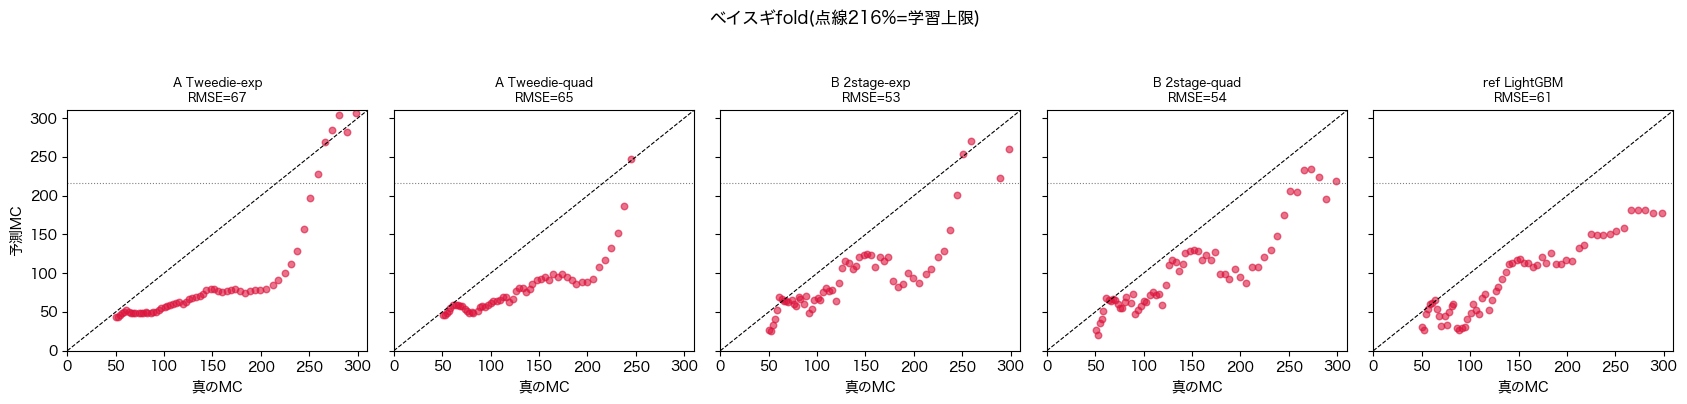

In [4]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['font.family']=['Hiragino Sans','AppleGothic','sans-serif']
matplotlib.rcParams['axes.unicode_minus']=False
ced=sp=='ベイスギ'; show=['A Tweedie-exp','A Tweedie-quad','B 2stage-exp','B 2stage-quad','ref LightGBM']
fig,ax=plt.subplots(1,len(show),figsize=(3.4*len(show),3.8),sharex=True,sharey=True)
for a,mn in zip(ax,show):
    m=MODELS[mn](); m.fit(Fmat[~ced],mc[~ced]); p=np.asarray(m.predict(Fmat[ced])).ravel()
    a.scatter(mc[ced],p,s=22,alpha=.6,c='crimson')
    a.plot([0,310],[0,310],'k--',lw=.8); a.axhline(216,color='gray',ls=':',lw=.8)
    a.set_xlim(0,310);a.set_ylim(0,310); a.set_title(f'{mn}\nRMSE={res[mn]["ベイスギ"]:.0f}',fontsize=8.5)
    a.set_xlabel('真のMC')
ax[0].set_ylabel('予測MC')
plt.suptitle('ベイスギfold(点線216%=学習上限)',y=1.05); plt.tight_layout(); plt.show()

## A×B(exp) 重み付きアンサンブル
`pred = w·A + (1−w)·B`。A=Tweedie-exp(macro良) と B=2stage-exp(外挿良) を重み w で混合し、LOSO macro と ベイスギ(外挿) のトレードオフを w で掃引。各foldで両モデルを学習側fit(リーク無し)。

In [5]:
# 各foldで A と B の予測を一度だけ算出 → 重み掃引は予測の線形結合で高速に
def fold_preds():
    PA=np.zeros(len(mc)); PB=np.zeros(len(mc))
    for s in species:
        te=sp==s; trn=~te
        a=TweedieA('exp').fit(Fmat[trn],mc[trn]); PA[te]=a.predict(Fmat[te])
        b=TwoStageB('exp').fit(Fmat[trn],mc[trn]); PB[te]=b.predict(Fmat[te])
    return PA,PB
PA,PB=fold_preds()
def macro_cedar(p):
    per={s:np.sqrt(np.mean((p[sp==s]-mc[sp==s])**2)) for s in species}
    return np.mean(list(per.values())), per['ベイスギ'], per

ws=np.linspace(0,1,21)
rows=[]
for w in ws:
    ma,cs,_=macro_cedar(w*PA+(1-w)*PB); rows.append((w,ma,cs))
sweep=pd.DataFrame(rows,columns=['w(A重み)','macro','ベイスギ'])
best=sweep.loc[sweep.macro.idxmin()]
print('macro最小: w=%.2f  macro=%.2f  ベイスギ=%.1f  (w=1:Aのみ, w=0:Bのみ)'
      %(best['w(A重み)'],best['macro'],best['ベイスギ']))
display(sweep.iloc[::2].round(2).reset_index(drop=True))

/Users/haru/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/haru/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/haru/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/haru/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/haru/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


...

/Users/haru/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/haru/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


macro最小: w=0.80  macro=26.46  ベイスギ=63.7  (w=1:Aのみ, w=0:Bのみ)


/Users/haru/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,w(A重み),macro,ベイスギ
0,0.0,29.47,52.85
1,0.1,28.80,53.81
2,0.2,28.21,54.90
3,0.3,27.70,56.11
4,0.4,27.27,57.44
5,0.5,26.93,58.87
6,0.6,26.68,60.40
7,0.7,26.52,62.03
8,0.8,26.46,63.74
9,0.9,26.51,65.53


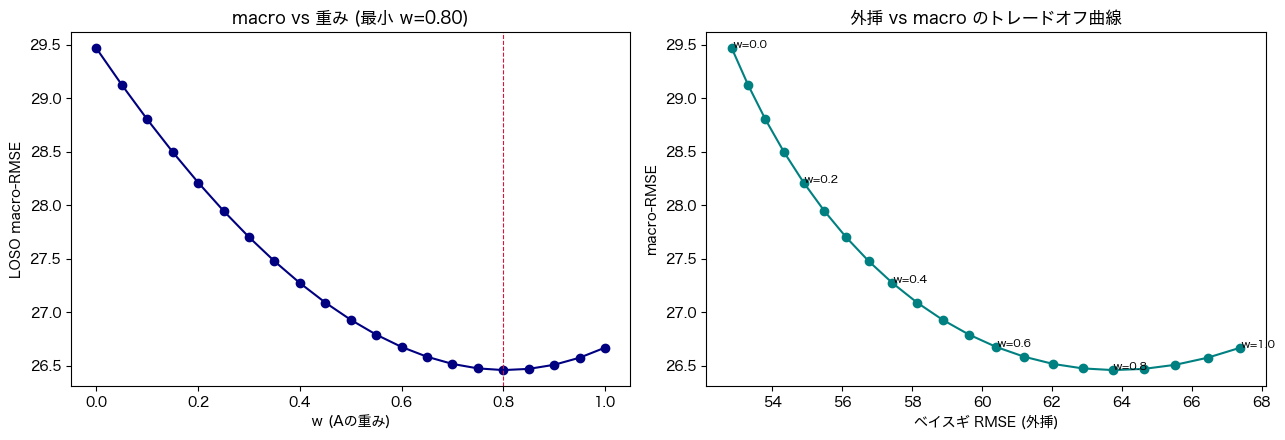

In [6]:
wcol='w(A重み)'; wbest=best[wcol]
fig,ax=plt.subplots(1,2,figsize=(13,4.5))
ax[0].plot(sweep[wcol],sweep['macro'],'o-',color='navy')
ax[0].axvline(wbest,color='crimson',ls='--',lw=.8)
ax[0].set_xlabel('w (Aの重み)'); ax[0].set_ylabel('LOSO macro-RMSE')
ax[0].set_title('macro vs 重み (最小 w=%.2f)'%wbest)
ax[1].plot(sweep['ベイスギ'],sweep['macro'],'o-',color='teal')
for _,r in sweep.iloc[::4].iterrows():
    ax[1].annotate('w=%.1f'%r[wcol],(r['ベイスギ'],r['macro']),fontsize=8)
ax[1].set_xlabel('ベイスギ RMSE (外挿)'); ax[1].set_ylabel('macro-RMSE')
ax[1].set_title('外挿 vs macro のトレードオフ曲線')
plt.tight_layout(); plt.show()

## 樹種別 真値 vs 予測(LOSO)
横軸=樹種内サンプル番号(樹種ごとに0始まり)、縦軸=含水率。真値とLOSO予測(A / B / アンサンブルw=0.5)を重ねる。

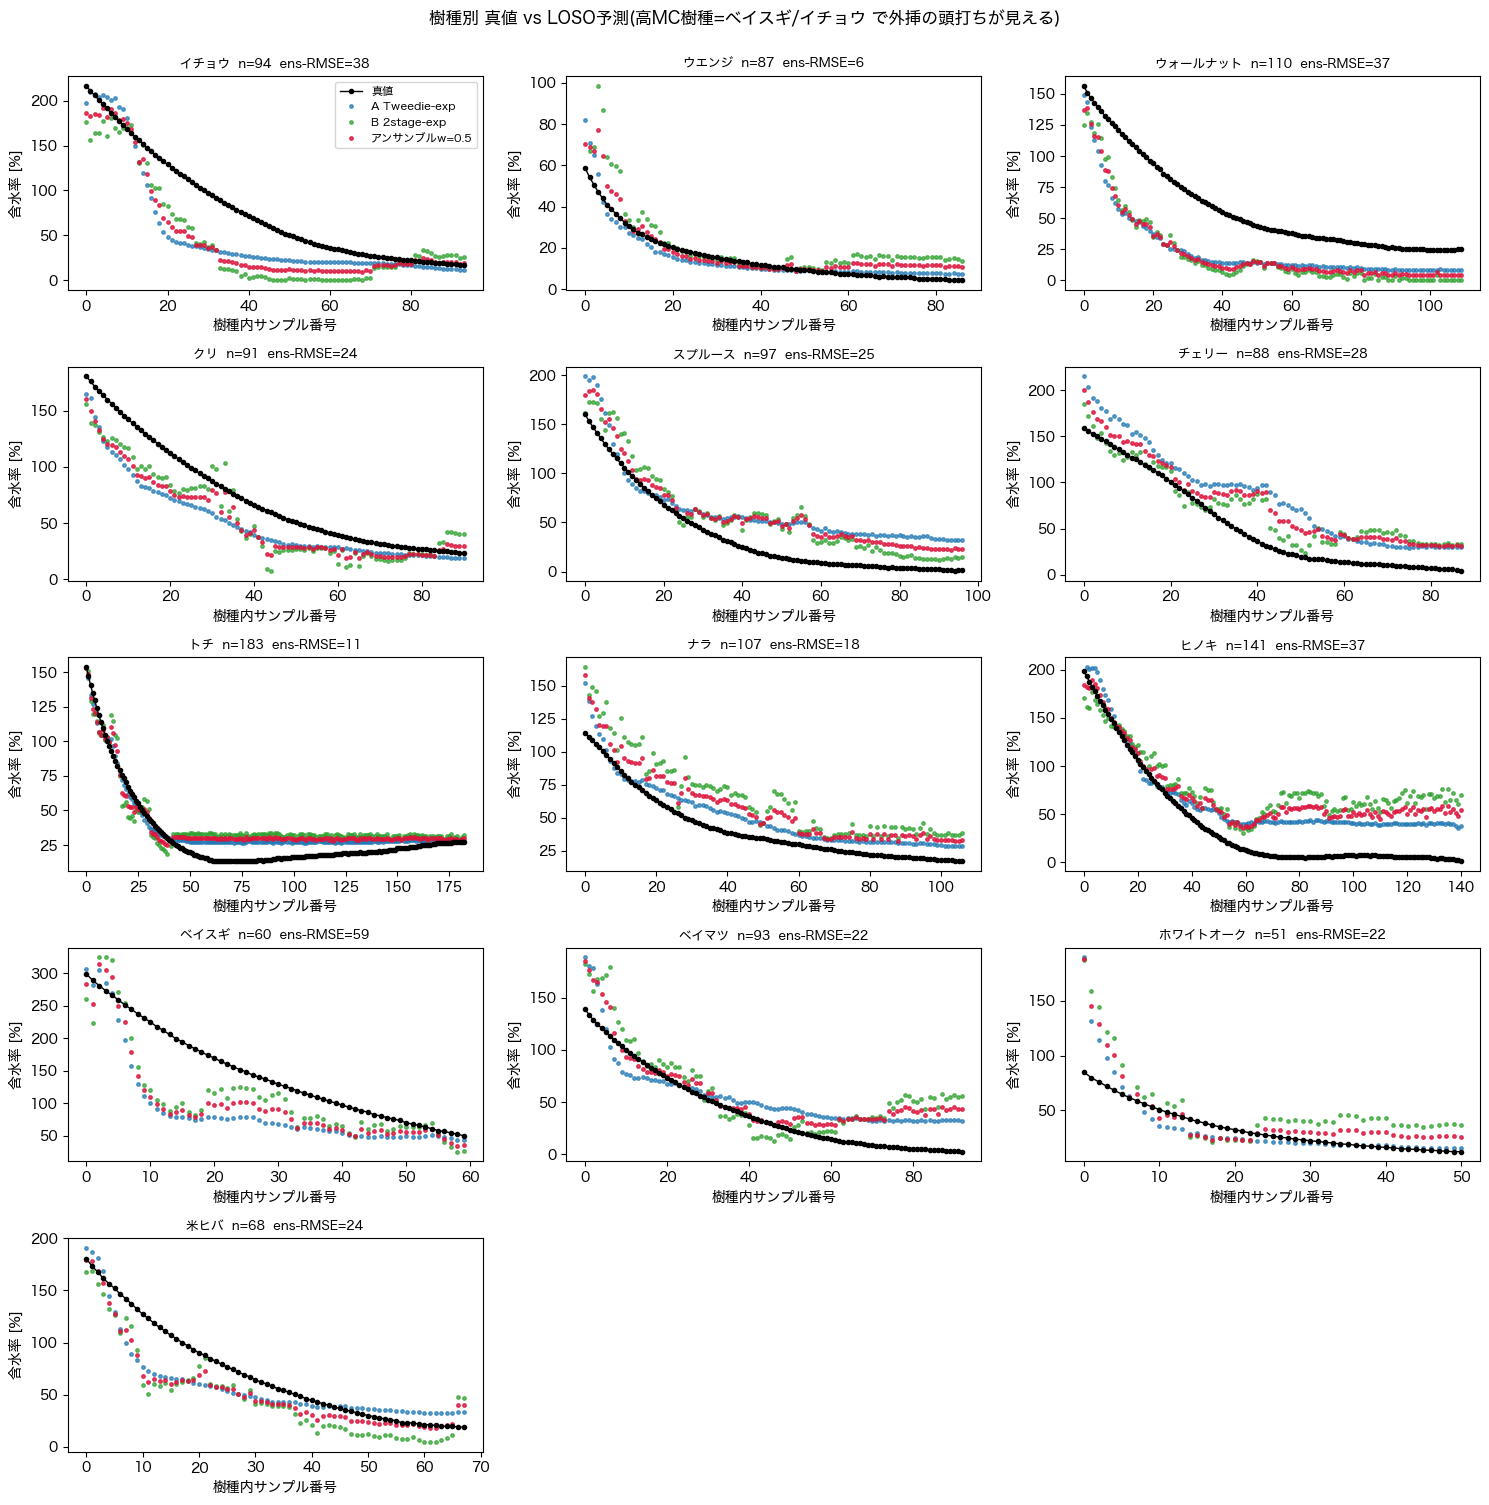

In [7]:
W=0.5; ENS=W*PA+(1-W)*PB   # アンサンブル予測(w=0.5)
SORT_BY_MC=False            # True にすると真値MC昇順で並べ替え(見やすい)
ncol=3; nrow=int(np.ceil(len(species)/ncol))
fig,ax=plt.subplots(nrow,ncol,figsize=(15,3.0*nrow)); ax=ax.ravel()
for i,s in enumerate(species):
    m=np.where(sp==s)[0]                       # 樹種sのサンプル(元の出現順)
    o=m[np.argsort(mc[m])] if SORT_BY_MC else m
    x=np.arange(len(o))                        # 樹種内サンプル番号(0始まり)
    a=ax[i]
    a.plot(x,mc[o],'-o',color='k',ms=3,lw=1,label='真値',zorder=3)
    a.plot(x,PA[o],'.',color='tab:blue',ms=5,alpha=.7,label='A Tweedie-exp')
    a.plot(x,PB[o],'.',color='tab:green',ms=5,alpha=.7,label='B 2stage-exp')
    a.plot(x,ENS[o],'.',color='crimson',ms=5,alpha=.8,label='アンサンブルw=0.5')
    rmse=np.sqrt(np.mean((ENS[o]-mc[o])**2))
    a.set_title(f'{s}  n={len(o)}  ens-RMSE={rmse:.0f}',fontsize=9)
    a.set_xlabel('樹種内サンプル番号'); a.set_ylabel('含水率 [%]')
for j in range(len(species),len(ax)): ax[j].axis('off')
ax[0].legend(fontsize=8)
plt.suptitle('樹種別 真値 vs LOSO予測(高MC樹種=ベイスギ/イチョウ で外挿の頭打ちが見える)',y=1.0)
plt.tight_layout(); plt.show()

## quad × exp シンプルアンサンブル
exp基底の加法モデルと quad基底の加法モデル(どちらも Ridge)を1つずつ作り、
`pred = w·exp + (1−w)·quad` で重み混合して LOSO macro / ベイスギ(外挿) を掃引する。

exp単独 : macro=25.99 ベイスギ=62.2
quad単独: macro=32.28 ベイスギ=58.0
macro最小: w=0.90 macro=25.86 ベイスギ=61.2 (w=1:expのみ, w=0:quadのみ)


,w(exp重み),macro,ベイスギ
0,0.0,32.28,58.04
1,0.1,31.39,57.88
2,0.2,30.52,57.85
3,0.3,29.69,57.95
4,0.4,28.89,58.18
5,0.5,28.13,58.54
6,0.6,27.41,59.02
7,0.7,26.76,59.63
8,0.8,26.20,60.36
9,0.9,25.86,61.21


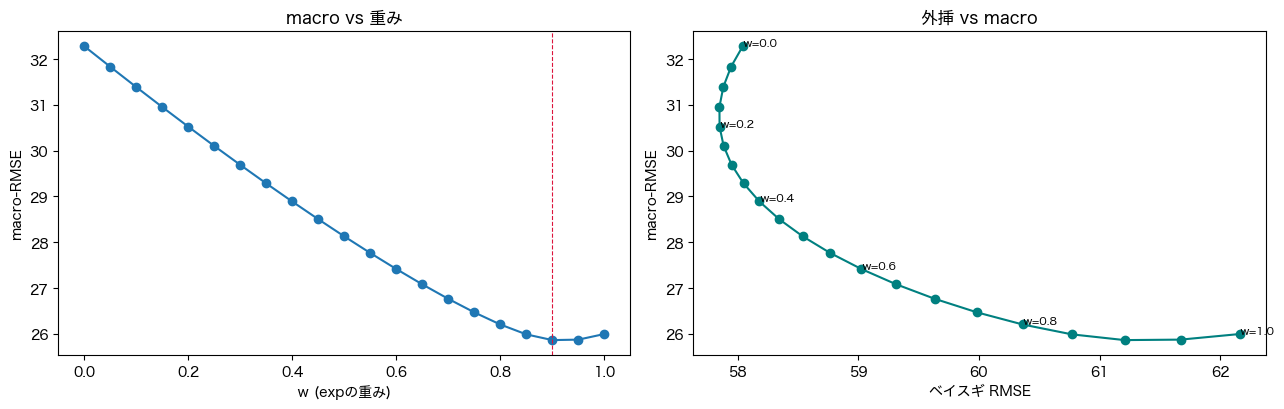

In [8]:
# exp基底 / quad基底 の加法Ridge(外挿可)。標準化は学習側でfit。
class AddRidge:
    def __init__(self, basis='exp', alpha=1.0): self.basis=basis; self.alpha=alpha
    def _phi(self,Z): return exp_basis(Z,self.B) if self.basis=='exp' else quad_basis(Z)
    def fit(self,X,y):
        self.s=Std().fit(X); Z=self.s.z(X)
        if self.basis=='exp': self.B=fit_expB(Z,y)
        P=self._phi(Z); self.ps=Std().fit(P)
        self.m=Ridge(self.alpha).fit(self.ps.z(P),y); return self
    def predict(self,X):
        Z=self.s.z(X); return np.clip(self.m.predict(self.ps.z(self._phi(Z))),0,400)

# 各foldで exp/quad のOOF予測を算出
def oof_pred(mf):
    p=np.zeros(len(mc))
    for s in species:
        te=sp==s; trn=~te
        p[te]=mf().fit(Fmat[trn],mc[trn]).predict(Fmat[te])
    return p
Pexp =oof_pred(lambda:AddRidge('exp'))
Pquad=oof_pred(lambda:AddRidge('quad'))

def mac_ced(p):
    per={s:np.sqrt(np.mean((p[sp==s]-mc[sp==s])**2)) for s in species}
    return np.mean(list(per.values())), per['ベイスギ']
ws=np.linspace(0,1,21)
sw=pd.DataFrame([(w,*mac_ced(w*Pexp+(1-w)*Pquad)) for w in ws],
                columns=['w(exp重み)','macro','ベイスギ'])
b=sw.loc[sw.macro.idxmin()]
print('exp単独 : macro=%.2f ベイスギ=%.1f'%mac_ced(Pexp))
print('quad単独: macro=%.2f ベイスギ=%.1f'%mac_ced(Pquad))
print('macro最小: w=%.2f macro=%.2f ベイスギ=%.1f (w=1:expのみ, w=0:quadのみ)'
      %(b['w(exp重み)'],b['macro'],b['ベイスギ']))
display(sw.iloc[::2].round(2).reset_index(drop=True))

fig,ax=plt.subplots(1,2,figsize=(13,4.2))
ax[0].plot(sw['w(exp重み)'],sw['macro'],'o-'); ax[0].axvline(b['w(exp重み)'],color='crimson',ls='--',lw=.8)
ax[0].set_xlabel('w (expの重み)'); ax[0].set_ylabel('macro-RMSE'); ax[0].set_title('macro vs 重み')
ax[1].plot(sw['ベイスギ'],sw['macro'],'o-',color='teal')
for _,r in sw.iloc[::4].iterrows(): ax[1].annotate('w=%.1f'%r['w(exp重み)'],(r['ベイスギ'],r['macro']),fontsize=8)
ax[1].set_xlabel('ベイスギ RMSE'); ax[1].set_ylabel('macro-RMSE'); ax[1].set_title('外挿 vs macro')
plt.tight_layout(); plt.show()

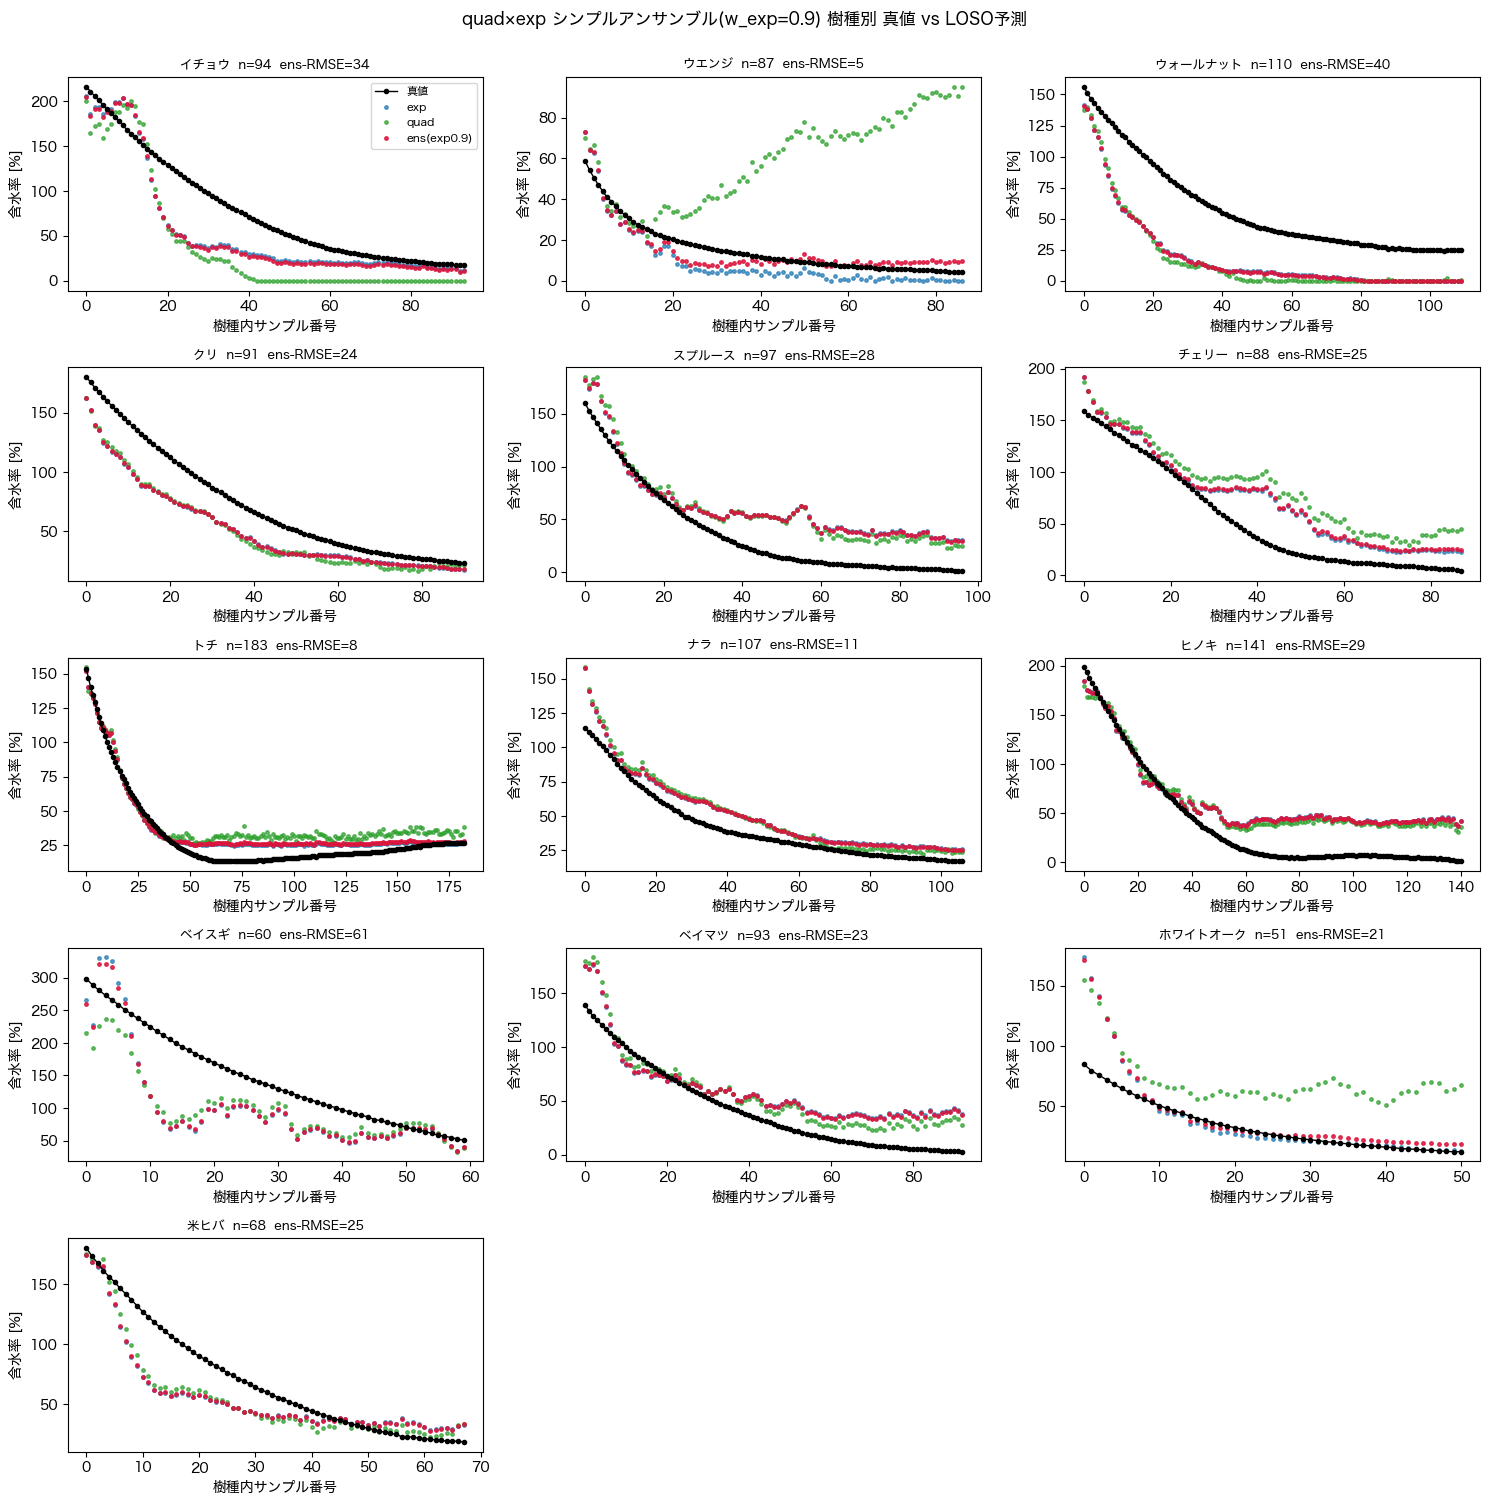

In [9]:
# quad×exp シンプルアンサンブルの 樹種別 真値 vs 予測(LOSO)
W_EXP=0.9; ENSqe=W_EXP*Pexp+(1-W_EXP)*Pquad   # macro最小近傍
SORT_BY_MC=False
ncol=3; nrow=int(np.ceil(len(species)/ncol))
fig,ax=plt.subplots(nrow,ncol,figsize=(15,3.0*nrow)); ax=ax.ravel()
for i,s in enumerate(species):
    m=np.where(sp==s)[0]; o=m[np.argsort(mc[m])] if SORT_BY_MC else m
    x=np.arange(len(o)); a=ax[i]
    a.plot(x,mc[o],'-o',color='k',ms=3,lw=1,label='真値',zorder=3)
    a.plot(x,Pexp[o],'.',color='tab:blue',ms=5,alpha=.7,label='exp')
    a.plot(x,Pquad[o],'.',color='tab:green',ms=5,alpha=.7,label='quad')
    a.plot(x,ENSqe[o],'.',color='crimson',ms=5,alpha=.85,label='ens(exp0.9)')
    rmse=np.sqrt(np.mean((ENSqe[o]-mc[o])**2))
    a.set_title(f'{s}  n={len(o)}  ens-RMSE={rmse:.0f}',fontsize=9)
    a.set_xlabel('樹種内サンプル番号'); a.set_ylabel('含水率 [%]')
for j in range(len(species),len(ax)): ax[j].axis('off')
ax[0].legend(fontsize=8)
plt.suptitle('quad×exp シンプルアンサンブル(w_exp=0.9) 樹種別 真値 vs LOSO予測',y=1.0)
plt.tight_layout(); plt.show()